# Enterprise Data Reconciliation & Business Intelligence Dashboard

## Project Overview

This project demonstrates an end-to-end ETL (Extract, Transform, Load) pipeline using Python, SQL, Regular Expressions, and Pandas. Data is collected from multiple sources, cleaned, transformed, merged, and analysed to generate business insights and visualizations.

### Data Sources
- SQLite Database (enterprise_database.db)
- Server Log File (server_logs.txt)
- Daily Exchange Rates (daily_exchange_rates.csv)

### Objectives
- Extract structured user information from a SQL database.
- Parse unstructured transaction logs using Regular Expressions.
- Merge transactions with daily exchange rates.
- Convert EUR transactions into USD.
- Analyse customer spending and product performance.
- Build visualizations for business decision-making.

# Phase 1: SQL Database Extraction

## Objective

The first step of the ETL pipeline is to extract user information from the SQLite database. The database contains historical user records where a single user may appear multiple times due to status updates.

In this phase:
- Connect to the SQLite database.
- Identify available tables.
- Extract user information.
- Perform initial data exploration to understand the dataset structure.

This represents the **Extract** stage of the ETL process.

In [15]:
# ===================================================================
# PHASE 1: SQL EXTRACTION
# ===================================================================
import sqlite3
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import time

t0 = time.time()

conn = sqlite3.connect('enterprise_database.db')

# The users table is a HISTORICAL LOG: a user_id can appear 2-3 times
# (Pending -> Active -> Suspended) as their status changed over time.
# We only want each user's *latest* row, then keep the ones that are 'Active'.

# ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY updated_at DESC) assigns
# rn=1 to the most recent row for every user_id. Filtering rn=1 collapses
# the history down to "current state per user" -- this is the standard
# SCD (Slowly Changing Dimension) pattern used in real warehouses.


query = '''
SELECT user_id, name, status, updated_at
FROM (
    SELECT *,
           ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY updated_at DESC) AS rn
    FROM users
) ranked
WHERE rn = 1 AND status = 'Active'
'''

df_active_users = pd.read_sql(query, conn)
print(f"Active users: {df_active_users.shape[0]}")
df_active_users.head()

Active users: 14183


,user_id,name,status,updated_at
0,U-00001,User_U-00001,Active,2023-01-28 14:00:00
1,U-00003,User_U-00003,Active,2023-01-22 14:00:00
2,U-00005,User_U-00005,Active,2023-01-17 14:00:00
3,U-00006,User_U-00006,Active,2023-01-05 14:00:00
4,U-00007,User_U-00007,Active,2023-01-27 14:00:00


# Phase 2: Server Log Processing using Regular Expressions

## Objective

The server log file contains more than 100,000 raw log entries. Unlike structured tables, transaction information is embedded inside text strings.

The objective of this phase is to:
- Read raw log data.
- Remove failed transactions.
- Extract transaction information using Regular Expressions.
- Convert the extracted information into a structured DataFrame.

This represents the **Transform** stage of the ETL process.

In [16]:
# ===============================================
# PHASE 2: REGEX & UNSTRUCTURED DATA WRANGLING
# ===============================================

df_logs = pd.read_csv('server_logs.txt')

# Drop ERROR rows first. Note: this is a *vectorized* boolean mask,
# not a Python for-loop -- critical for the 100k-row / 2-min requirement.
df_logs = df_logs[~df_logs['Raw_Server_Log'].str.contains('ERROR')]

# Single regex with named capture groups pulls all 4 fields out of the
# raw string in ONE vectorized .str.extract() call (no loops, no .apply()).
# Example line:
# [2023-03-15 00:00:00] INFO: Transaction processed. payload={"u":"U-19484", "item_code":"PRD-874", "eur_val":3404.44}

pattern = (
    r'\[(?P<Date>\d{4}-\d{2}-\d{2}) [\d:]+\] \w+: .*?'
    r'"u":"(?P<User_ID>[^"]+)", '
    r'"item_code":"(?P<Product_ID>[^"]+)", '
    r'"eur_val":(?P<Euro_Value>[\d.]+)'
)

extracted_data = df_logs['Raw_Server_Log'].str.extract(pattern)


# Cast types (still vectorized -- pandas casts the whole column at once)
extracted_data['Euro_Value'] = extracted_data['Euro_Value'].astype(float)
extracted_data['Date'] = pd.to_datetime(extracted_data['Date'])

print(f"Rows after dropping ERROR + regex extraction: {extracted_data.shape[0]}")
print(f"Any failed extractions (nulls)? {extracted_data.isna().sum().sum()}")
extracted_data.head()

Rows after dropping ERROR + regex extraction: 94902
Any failed extractions (nulls)? 0


,Date,User_ID,Product_ID,Euro_Value
0,2023-03-15,U-19484,PRD-874,3404.44
2,2023-05-09,U-18932,PRD-905,3406.21
3,2023-10-21,U-15882,PRD-284,164.08
4,2023-01-10,U-22781,PRD-665,26.80
5,2023-05-23,U-13348,PRD-589,4964.77


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Phase 3: Financial Reconciliation

## Objective

Transactions are recorded in Euros, whereas business reporting requires values in US Dollars.

To perform the conversion:
- Daily exchange rates are loaded.
- Transaction dates are matched with exchange rate dates.
- Transactions are converted from EUR to USD.

This step combines multiple datasets into one unified analytical dataset.

In [18]:
# ==============================================
# PHASE 3: FINANCIAL RECONCILIATION & MERGING
# ==============================================

rates = pd.read_csv('daily_exchange_rates.csv')
rates['Date'] = pd.to_datetime(rates['Date'])

# IMPORTANT: sort by Date before ffill. ffill just propagates the last valid
# value forward row-by-row in the CURRENT order of the DataFrame, so if the
# rows weren't already in chronological order this would silently produce
# garbage.
rates = rates.sort_values('Date').reset_index(drop=True)

# Weekend rows have NaN exchange rates (market closed). Forward-fill rolls
# Friday's rate into Saturday and Sunday so an INNER JOIN doesn't drop them.
rates['EUR_to_USD'] = rates['EUR_to_USD'].ffill()

assert rates['EUR_to_USD'].isna().sum() == 0, "Still missing rates!"

# Merge transactions -> exchange rates on Date
merged = extracted_data.merge(rates, on='Date', how='left')
print(f"Nulls in EUR_to_USD after merge: {merged['EUR_to_USD'].isna().sum()}")  # should be 0

# Merge -> active users on User_ID (inner join: only keep txns from Active users)

# Note: row count drops from 94,902 -> 53,899 here. This is expected:
# the inner join only keeps transactions from users whose *latest* status
# is 'Active' (14,183 of the 25,000 total users). Transactions from
# Pending/Suspended users are intentionally excluded per the assignment.

df_final = merged.merge(
    df_active_users, left_on='User_ID', right_on='user_id', how='inner'
)

print(f"Data pipeline runtime (Phases 1-3): {time.time() - t0:.2f}s")

df_final['USD_Revenue'] = df_final['Euro_Value'] * df_final['EUR_to_USD']

print(f"df_final shape: {df_final.shape}")
df_final.head()

Nulls in EUR_to_USD after merge: 0
Data pipeline runtime (Phases 1-3): 22.18s
df_final shape: (53899, 10)


,Date,User_ID,Product_ID,Euro_Value,EUR_to_USD,user_id,name,status,updated_at,USD_Revenue
0,2023-03-15,U-19484,PRD-874,3404.44,1.178232,U-19484,User_U-19484,Active,2023-01-11 14:00:00,4011.220772
1,2023-10-21,U-15882,PRD-284,164.08,1.075350,U-15882,User_U-15882,Active,2023-01-16 14:00:00,176.443420
2,2023-01-10,U-22781,PRD-665,26.80,1.127128,U-22781,User_U-22781,Active,2023-01-07 14:00:00,30.207030
3,2023-10-20,U-22062,PRD-363,48.63,1.075350,U-22062,User_U-22062,Active,2023-01-05 14:00:00,52.294268
4,2023-12-02,U-22146,PRD-223,960.60,1.066142,U-22146,User_U-22146,Active,2023-01-18 14:00:00,1024.135923


# Phase 4: Business Analysis & Visualization

## Objective

The cleaned and reconciled dataset is analysed to generate meaningful business insights.

The analysis focuses on:
- Total Revenue
- Average Transaction Value
- Highest Value Transactions
- Top Customers
- Best Selling Products
- Monthly Revenue Trends

The results are visualized to support business decision-making.

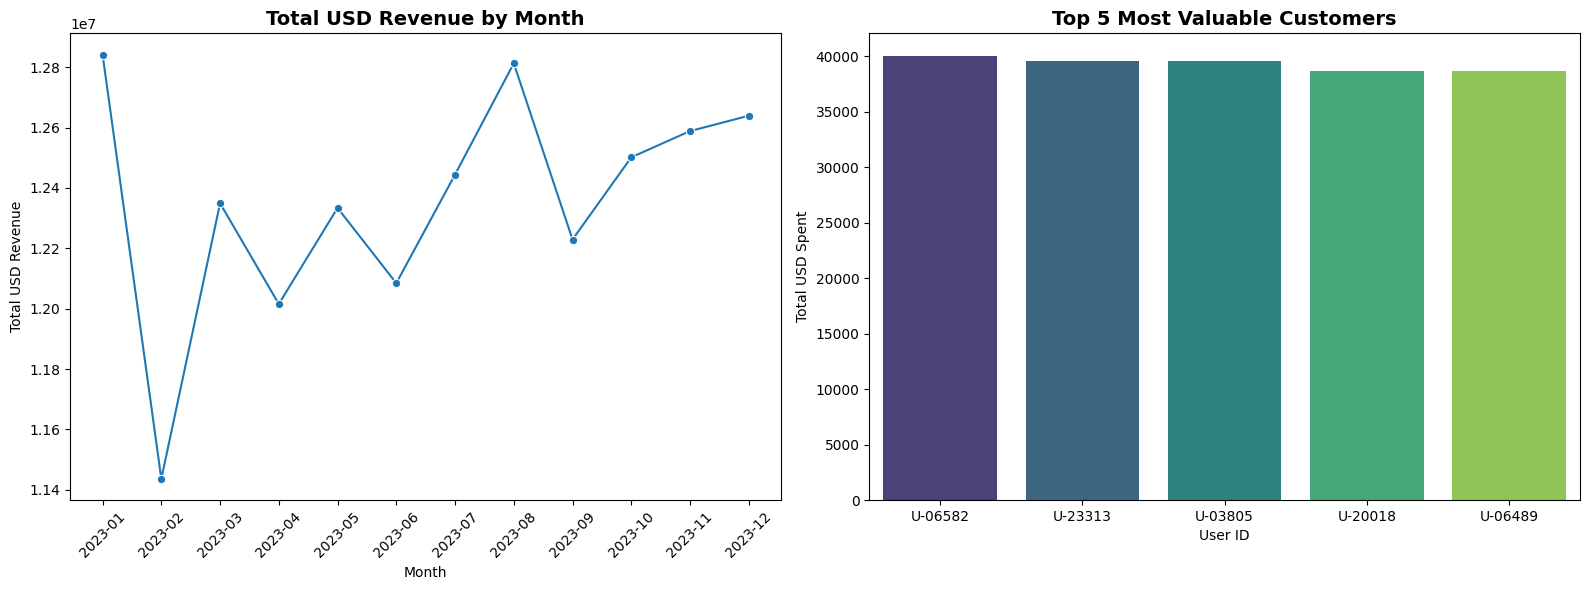


Top 5 Customers:
User_ID  name        
U-06582  User_U-06582    40050.988262
U-23313  User_U-23313    39555.806629
U-03805  User_U-03805    39529.945085
U-20018  User_U-20018    38649.965242
U-06489  User_U-06489    38629.142146
Name: USD_Revenue, dtype: float64

Total pipeline runtime: 40.70s


In [19]:
# ===================================================================
# PHASE 4: AGGREGATION & VISUALIZATION (CFO DASHBOARD)
# ===================================================================

df_final['Month'] = df_final['Date'].dt.to_period('M').astype(str)

# 1. Total USD revenue by month
monthly_revenue = df_final.groupby('Month')['USD_Revenue'].sum().sort_index()

# 2. Top 5 customers by total USD spent
top5_customers = (
    df_final.groupby(['User_ID', 'name'])['USD_Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Revenue by Month
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o', ax=axes[0])
axes[0].set_title('Total USD Revenue by Month', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total USD Revenue')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Top 5 Customers
top5_labels = [f"{uid}" for uid, name in top5_customers.index]
sns.barplot(x=top5_labels, y=top5_customers.values, hue=top5_labels, palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Top 5 Most Valuable Customers', fontsize=14, fontweight='bold')
axes[1].set_xlabel('User ID')
axes[1].set_ylabel('Total USD Spent')

plt.tight_layout()
plt.savefig('cfo_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 Customers:")
print(top5_customers)

print(f"\nTotal pipeline runtime: {time.time() - t0:.2f}s")


In [20]:
print(f"Total reconciled USD revenue (Active users only): ${df_final['USD_Revenue'].sum():,.2f}")
print(f"Transactions excluded due to inactive/pending status: {94902 - len(df_final):,}")

Total reconciled USD revenue (Active users only): $148,274,622.91
Transactions excluded due to inactive/pending status: 41,003


# Project Conclusion

This project successfully demonstrates an end-to-end ETL pipeline by integrating data from multiple heterogeneous sources.

The workflow includes:
- Extracting structured data from a SQL database.
- Parsing unstructured server logs using Regular Expressions.
- Performing financial reconciliation using exchange rates.
- Converting transactions from EUR to USD.
- Analysing customer and product performance.
- Building visualizations for business intelligence.

The final dashboard provides actionable insights that can assist business stakeholders in monitoring revenue trends, customer behaviour, and product performance while demonstrating practical skills in SQL, Python, Pandas, Regular Expressions, ETL, and Data Analytics.